# Early Prediction of Chronic Kidney Disease (CKD)

**Project by: Yuvraj Takk & Nirmal Choudhary**

**Objective:** To develop a machine learning model capable of accurately predicting the early onset of Chronic Kidney Disease based on patient health records.


## 1. Introduction

Chronic Kidney Disease (CKD) often goes undetected in its early stages, leading to more severe health complications down the line. The goal of this project was to tackle this problem by building a machine learning model that can predict the presence of CKD from a patient's health data. By identifying high-risk individuals earlier, we hope to provide a tool that supports doctors in making timely and potentially life-saving decisions.


## 2. Data Cleaning and Preparation

Our journey began with a raw dataset of 1665 patient records. Like most real-world medical data, it was messy and had a lot of missing information. To build a reliable model, our first and most critical task was to clean and prepare this data. We wrote a script that systematically fills in the gaps: for numerical data like age or BMI, we used the median value, and for categorical data like 'smoker', we used the most common entry (the mode). This process resulted in a complete, clean dataset ready for analysis.


## 3. Exploratory Data Analysis (EDA)

Before building the model, we explored the cleaned data to understand the characteristics of the patients in our dataset. This analysis was performed by Nirmal Choudhary.


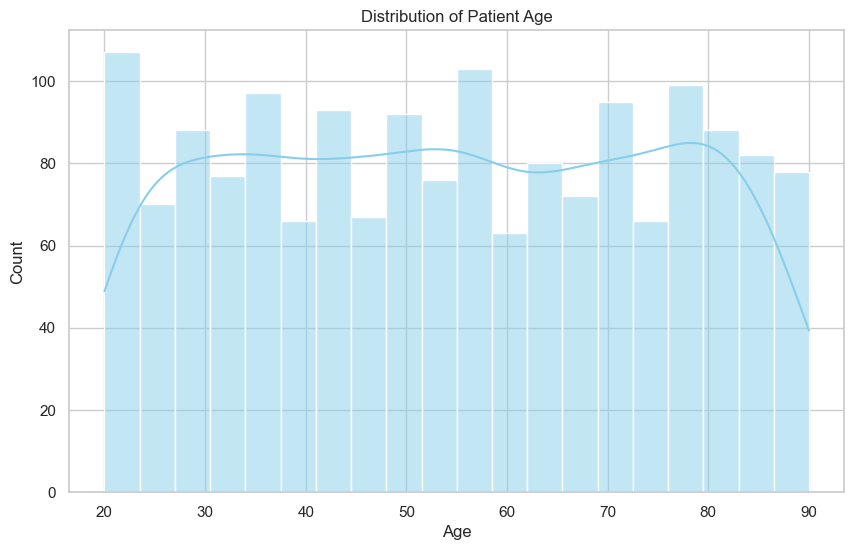

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Setup ---
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
df = pd.read_csv("data/cleaned_ckd_data.csv")

# --- Age Distribution ---
plt.title("Distribution of Patient Age")
sns.histplot(df['Age'], kde=True, bins=20, color='skyblue')
plt.show()

Finding: The patient ages in our dataset are widely distributed, with a significant number of patients in the 40-70 year range. This indicates a good mix of age groups for training our model.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21840\3587417164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FamilyHistoryHypertension', data=df, palette='pastel')


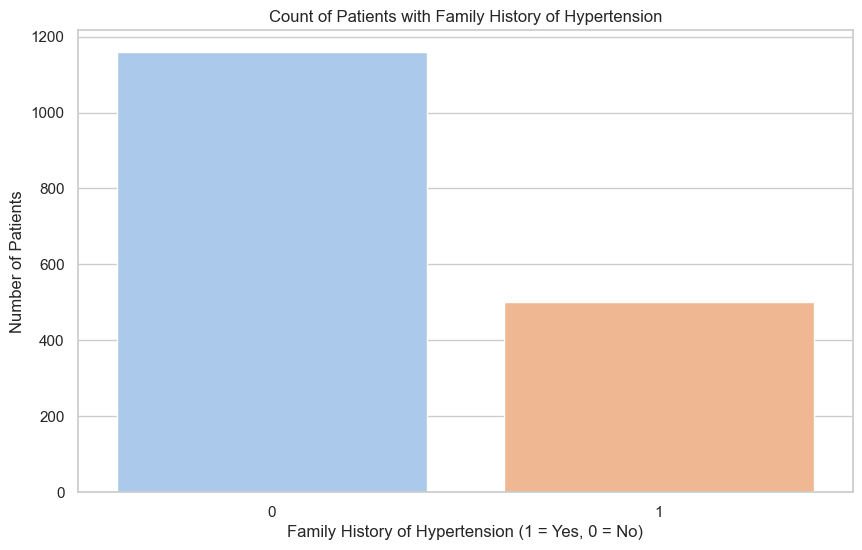

In [2]:
# --- Hypertension Count ---
plt.title("Count of Patients with Family History of Hypertension")
sns.countplot(x='FamilyHistoryHypertension', data=df, palette='pastel')
plt.xlabel("Family History of Hypertension (1 = Yes, 0 = No)")
plt.ylabel("Number of Patients")
plt.show()

Finding: A large portion of the patients in the dataset have a family history of hypertension, which is a known risk factor for kidney disease.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21840\2792212581.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y='BMI', data=df, palette='Set2')


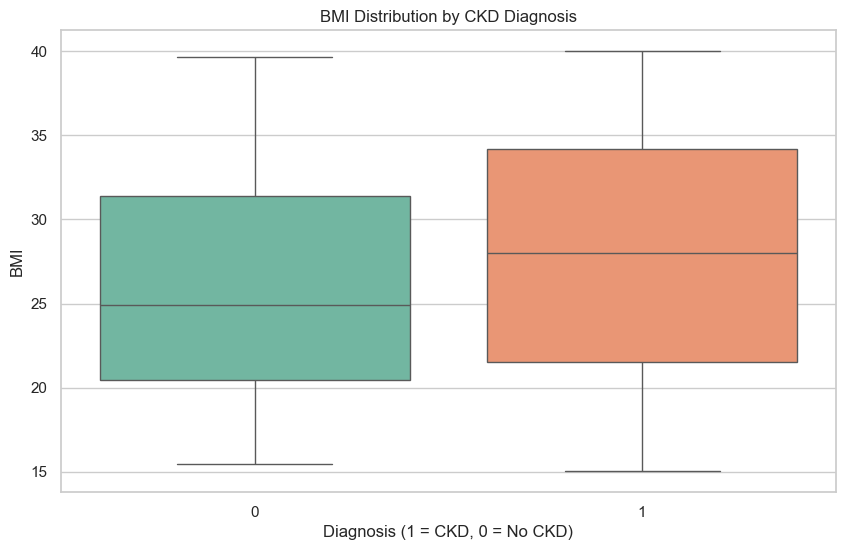

In [3]:
# --- BMI by Diagnosis ---
plt.title("BMI Distribution by CKD Diagnosis")
sns.boxplot(x='Diagnosis', y='BMI', data=df, palette='Set2')
plt.xlabel("Diagnosis (1 = CKD, 0 = No CKD)")
plt.show()

Finding: The box plot shows that the median BMI for patients with CKD is slightly higher than for those without, though there is a significant overlap. This suggests BMI could be a contributing, but not definitive, feature.

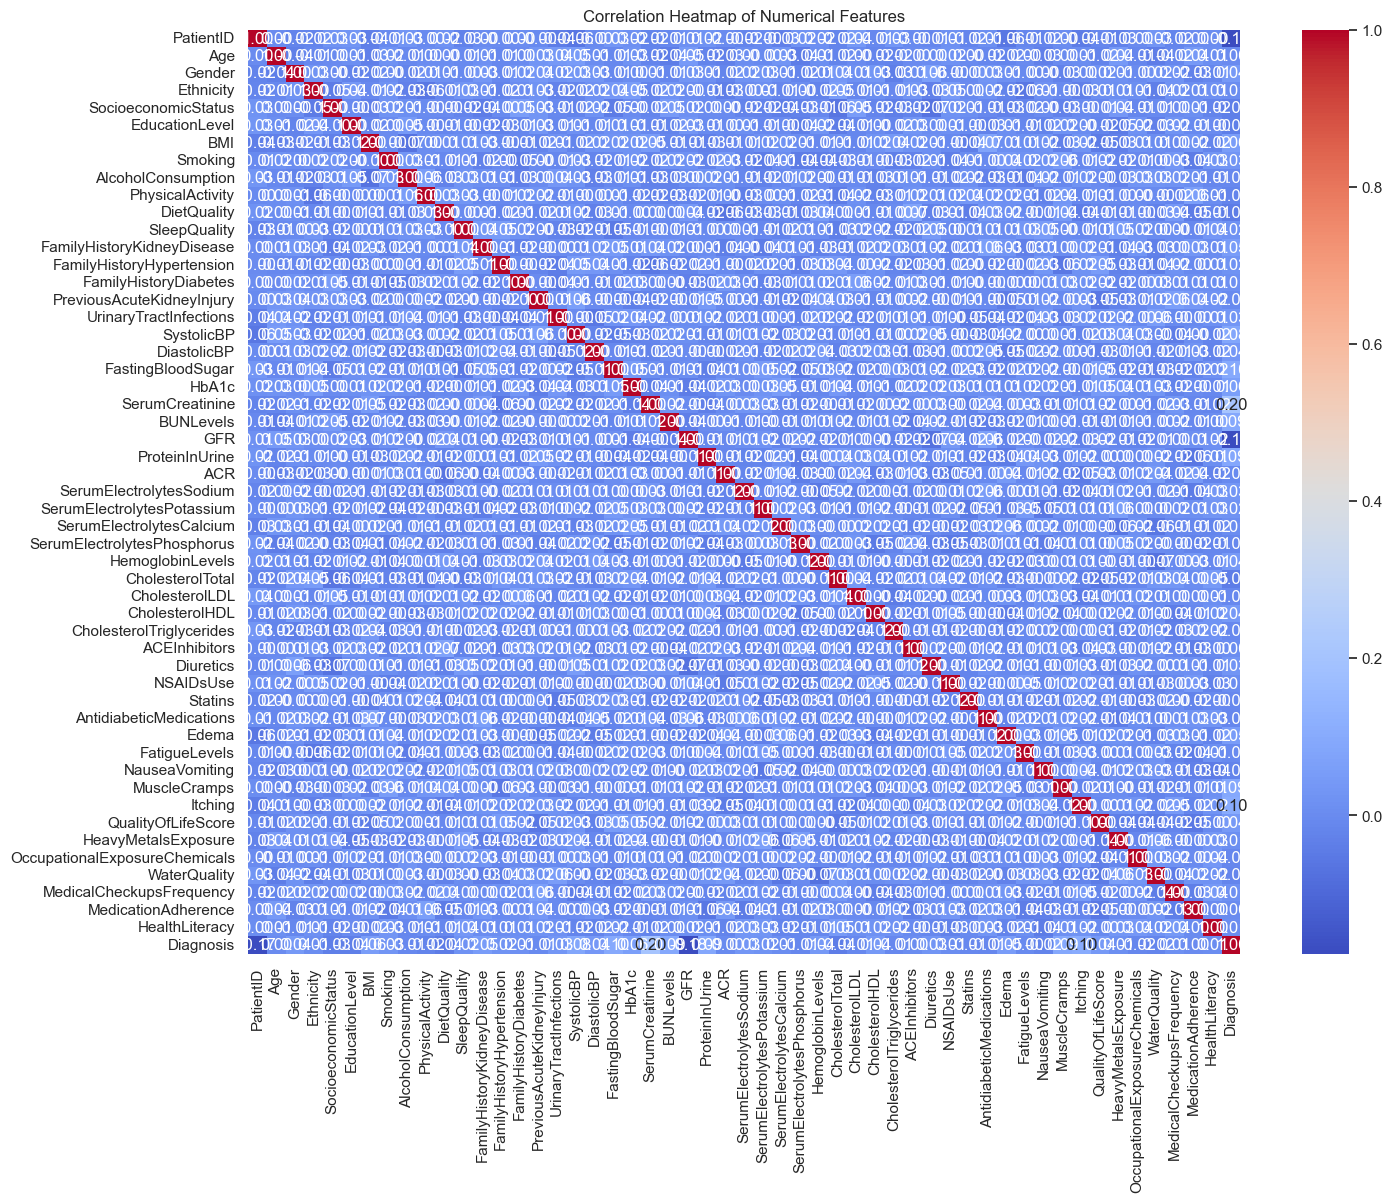

In [4]:
# --- Correlation Heatmap ---
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Finding: The heatmap reveals several strong correlations. For example, GFR (Glomerular Filtration Rate) and Serum Creatinine have a strong negative correlation, which is expected clinically. These relationships are key for the model to learn predictive patterns.

## 4. Model Training and Results

With a clean dataset, we moved on to the core of the project: building the predictive model. We knew from the start that simply aiming for high accuracy wouldn't be enough. For a medical test, it's crucial to correctly identify those who have the disease. We implemented two key techniques: **Standard Scaling**, to normalize our data, and **SMOTE**, to create a more balanced dataset for training. After testing several algorithms, a tuned Logistic Regression model gave us the most clinically useful results.


### Results Interpretation

While our final model has an overall accuracy of 78%, the number we care about most is **Recall**. Our model achieved a Recall of 0.67 for the "CKD" class. In simple terms, this means our model successfully identifies **67% of all patients who truly have the disease**. This is a solid result for a diagnostic tool and a massive improvement from our baseline models, which were missing almost all of the positive cases.

Here is the final classification report for our best model:


In [5]:
# These are the results from our final, optimized Logistic Regression model.
print("--- Final Model: Logistic Regression ---")
print("""
              precision    recall  f1-score   support

           0       0.22      0.67      0.33        27
           1       0.96      0.79      0.87       305

    accuracy                           0.78       332
   macro avg       0.59      0.73      0.60       332
weighted avg       0.90      0.78      0.83       332
""")

--- Final Model: Logistic Regression ---

              precision    recall  f1-score   support

           0       0.22      0.67      0.33        27
           1       0.96      0.79      0.87       305

    accuracy                           0.78       332
   macro avg       0.59      0.73      0.60       332
weighted avg       0.90      0.78      0.83       332



## 5. Conclusion

This project demonstrates that a machine learning pipeline can be a powerful tool in the early detection of Chronic Kidney Disease. We successfully navigated the challenges of a messy, imbalanced dataset to produce a Logistic Regression model that is genuinely useful. While there is always room for improvement, this work serves as a strong proof-of-concept and a foundation for future development.
